In [31]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
from defs import ts_onset_cess as ocd
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [32]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"

### Read in calculated recycling to add to the precipitation plots

In [33]:
Y1=2018
Y2=2024

datao = "/Volumes/New_5TB/ESA_F4R/2026_rho/bands/"
S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_HI" # L_M or L_HI
band = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
rho_xarr={}
for B in ['N','EQ','S']:
    print('running band:', B)
    #rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = xr.open_dataset(datao+L_NAME+"_"+S_NAME+"_"+B+"_rot_rho_era5_precipfiltered.nc",engine='netcdf4')
    rho_xarr[B] = rho_xarr[B].sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

running band: N
running band: EQ
running band: S


### Calculate roatational means for each month and band


In [34]:
#Monthly average plots - average rotation
rho_mon = {}
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for B in ['N','EQ','S']:
    rho_rot = rho_xarr[B]['rho'].mean('rot') 
    rho_mon[B] = rho_rot.groupby('time.month').mean(dim=('time','lat','lon'))
    rho_mon[B] = rho_mon[B].assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))

### Read in precip 
- do this for whole available ts and then sub-select years in next step for analysis

In [35]:
#Y1=1981
#Y2=2025
#for Y in range(Y1,Y2+1):
#    prp = xr.open_mfdataset('/Volumes/blue_wd/chirps_daily/chirps-v2.0.'+str(Y)+'.days_p05.nc')['precip']
#    prp = prp.rename({'latitude':'lat','longitude':'lon'})
#    prpN = prp.sel(lat=slice(5,12),lon=slice(10,31),drop=True).load()
#    prpEQ = prp.sel(lat=slice(-5,5),lon=slice(8,29),drop=True).load()
#    prpS = prp.sel(lat=slice(-15,-5),lon=slice(12,31),drop=True).load()
#    if Y==Y1:
#        prpaN = prpN
#        prpaEQ = prpEQ
#        prpaS = prpS
#    else:
#        prpaN = xr.concat([prpaN,prpN],dim='time')
#        prpaEQ = xr.concat([prpaEQ,prpEQ],dim='time')
#        prpaS = xr.concat([prpaS,prpS],dim='time')
#        prpN.close()
#        prpEQ.close()
#        prpS.close()
#prpaN.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc',engine='h5netcdf')
#prpaN.close()
#prpaEQ.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc',engine='h5netcdf')
#prpaEQ.close()
#prpaS.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc',engine='h5netcdf')
#prpaS.close()
#        

In [36]:
Y1=2018
Y2=2024
pr = {}
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/F4R_data/chirps_N.nc')['precip']
pr['N'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/F4R_data/chirps_EQ.nc')['precip']
pr['EQ'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/F4R_data/chirps_S.nc')['precip']
pr['S'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

In [37]:
hdo = xr.open_mfdataset(datac+'hdo_day_reg_regrid.nc') 
hdo = hdo.where(hdo['deltaD']<60,np.nan)
hdoN = hdo.sel(lat=slice(5,12),lon=slice(10,31),drop=True).load()
hdoEQ = hdo.sel(lat=slice(-5,5),lon=slice(8,29),drop=True).load()
hdoS = hdo.sel(lat=slice(-15,-5),lon=slice(12,31),drop=True).load()

## Equatorial Band

- Calculate the onset and cessation of full climatology for all seasons


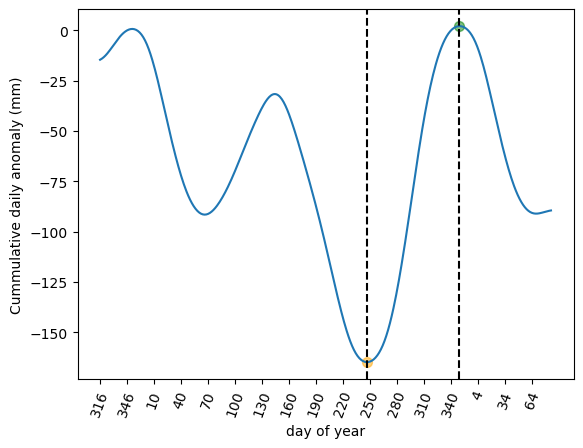

[260. 231. 238. 256. 255.]
[331.   8. 364. 346. 365.]
[nan nan nan nan nan]
[nan nan nan nan nan]
All years mean onset 1 248.0 All years mean cessation 1 282.8
All years mean onset 2 nan All years mean cessation 2 nan
----------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [38]:
#Equatorial Band

P = pr['EQ'] 

#Season timing
power_ratio,on1,ce1,on2,ce2,on3,ce3,on1_years,ce1_years,on2_years,ce2_years,on3_years,ce3_years = ocd.xarray_on_cess_point(P.mean(dim=("lat","lon")))

print(on1_years.values)
print(ce1_years.values)
print(on2_years.values)
print(ce2_years.values)
mean_onset_1 = on1_years.mean('year').values 
mean_cess_1 = ce1_years.mean('year').values 
mean_onset_2 = on2_years.mean('year').values 
mean_cess_2 = ce2_years.mean('year').values
print('All years mean onset 1', mean_onset_1, 'All years mean cessation 1', mean_cess_1)
print('All years mean onset 2', mean_onset_2, 'All years mean cessation 2', mean_cess_2)
print('----------------------------------------------------')


mean_onset_1 = 64
mean_cess_1 = 143
mean_onset_2 = 247
mean_cess_2 = 341


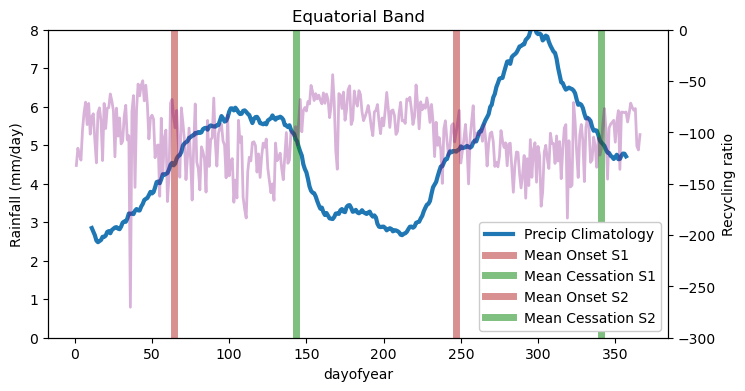

In [39]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(8, 4))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=mean_onset_1, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset S1')
plt.axvline(x=mean_cess_1, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation S1')
plt.axvline(x=mean_onset_2, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset S2')
plt.axvline(x=mean_cess_2, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation S2')
ax.set(ylim=(0,8), ylabel='Rainfall (mm/day)')

ax2 = ax.twinx()

#ax2.plot(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],linestyle='-',linewidth=2,color='purple',alpha=0.3)
hdop = hdoEQ['deltaD'].mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
ax2.plot(hdop['dayofyear'],hdop,linestyle='-',linewidth=2,color='purple',alpha=0.3)
#ax2.scatter(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],s=70,color='purple',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(-300,0), ylabel='Recycling ratio')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='lower right')

plt.title('Equatorial Band')
plt.savefig(datap+'EQ_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()



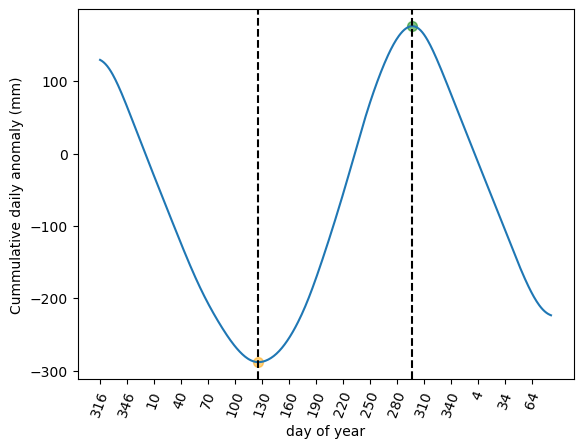

All years mean onset 1 126.2 All years mean cessation 1 298.2
All years mean onset 2 nan All years mean cessation 2 nan
----------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [40]:
#North Band

P = pr['N'] 

#Season timing
power_ratio,on1,ce1,on2,ce2,on3,ce3,on1_years,ce1_years,on2_years,ce2_years,on3_years,ce3_years = ocd.xarray_on_cess_point(P.mean(dim=("lat","lon")))

mean_onset_1 = on1_years.mean('year').values 
mean_cess_1 = ce1_years.mean('year').values 
mean_onset_2 = on2_years.mean('year').values 
mean_cess_2 = ce2_years.mean('year').values
print('All years mean onset 1', mean_onset_1, 'All years mean cessation 1', mean_cess_1)
print('All years mean onset 2', mean_onset_2, 'All years mean cessation 2', mean_cess_2)
print('----------------------------------------------------')

mean_onset_1 = 124
mean_cess_1 = 298


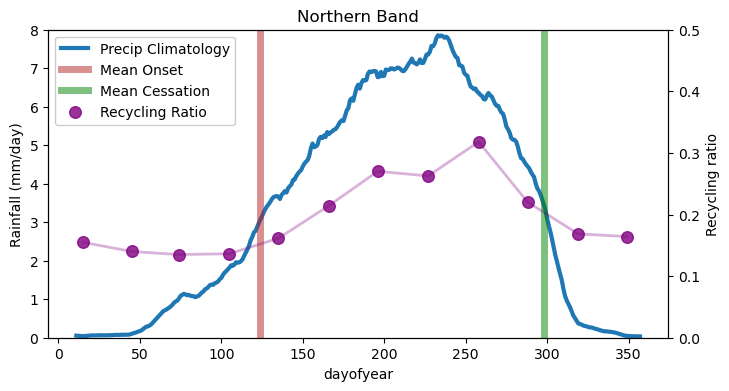

<Figure size 640x480 with 0 Axes>

In [41]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(8, 4))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=mean_onset_1, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset')
plt.axvline(x=mean_cess_1, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation')
ax.set(ylim=(0,8), ylabel='Rainfall (mm/day)')

ax2 = ax.twinx()

ax2.plot(rho_mon['N']['dayofyear'],rho_mon['N'],linestyle='-',linewidth=2,color='purple',alpha=0.3)
ax2.scatter(rho_mon['N']['dayofyear'],rho_mon['N'],s=70,color='purple',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.5),ylabel='Recycling ratio')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='upper left')

plt.title('Northern Band')
plt.savefig(datap+'N_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()

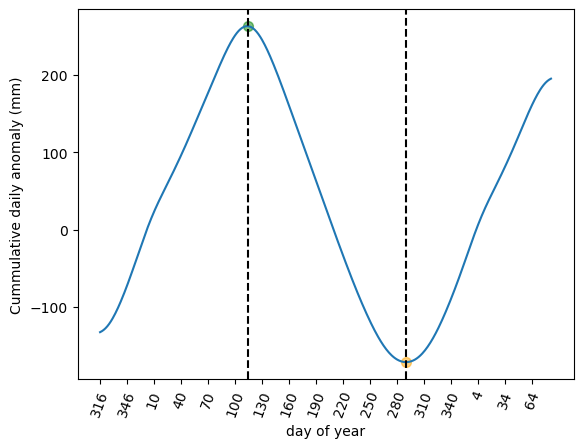

All years mean onset 1 289.4 All years mean cessation 1 114.6
All years mean onset 2 nan All years mean cessation 2 nan
----------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [42]:
#Southern Band

P = pr['S'] 

#Season timing
power_ratio,on1,ce1,on2,ce2,on3,ce3,on1_years,ce1_years,on2_years,ce2_years,on3_years,ce3_years = ocd.xarray_on_cess_point(P.mean(dim=("lat","lon")))

mean_onset_1 = on1_years.mean('year').values 
mean_cess_1 = ce1_years.mean('year').values 
mean_onset_2 = on2_years.mean('year').values 
mean_cess_2 = ce2_years.mean('year').values
print('All years mean onset 1', mean_onset_1, 'All years mean cessation 1', mean_cess_1)
print('All years mean onset 2', mean_onset_2, 'All years mean cessation 2', mean_cess_2)
print('----------------------------------------------------')

mean_onset_1 = 291
mean_cess_1 = 110


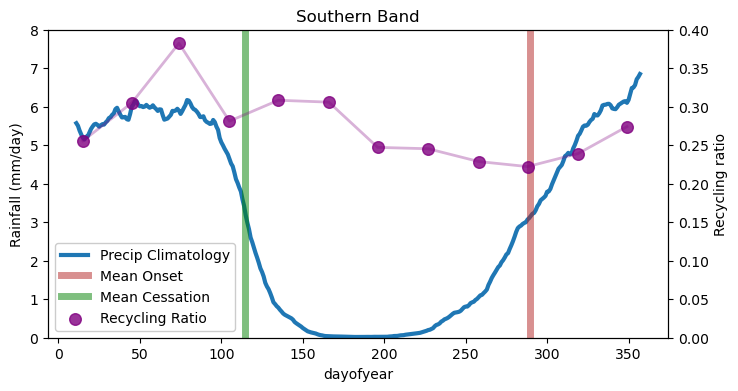

<Figure size 640x480 with 0 Axes>

In [43]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(8, 4))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

plt.axvline(x=on1_years.mean('year').values, color='firebrick', linestyle='-', linewidth=5,alpha=0.5,label='Mean Onset')
plt.axvline(x=ce1_years.mean('year').values, color='green', linestyle='-', linewidth=5,alpha=0.5,label='Mean Cessation')
ax.set(ylim=(0,8), ylabel='Rainfall (mm/day)')

ax2 = ax.twinx()

ax2.plot(rho_mon['S']['dayofyear'],rho_mon['S'],linestyle='-',linewidth=2,color='purple',alpha=0.3)
ax2.scatter(rho_mon['S']['dayofyear'],rho_mon['S'],s=70,color='purple',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling ratio')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2, labels + labels2, framealpha=1.0, loc='lower left')

plt.title('Southern Band')
plt.savefig(datap+'S_timing_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()